In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Proportion of variance explained by sites

In these plots, the units are in $v_s$, which is the expected contribution at sites under strong selection. This is defined as the following,
$$
v_s=2\frac{w^2}{nN},
$$
where $N$ is the population size, $w$ is the constant in the stabilizing selection model, and $n$ is the degree of pleiotropy.

## No pleiotropy

We let $S=2Ns$ be the scaled selection coefficient. When there is no pleiotropy ($n=1$), $a_1=\pm w\sqrt{s}$. In this setting, when selection is strong ($S>30$), 
$$
G(v)=exp(-2v),
$$
where $G(v)$ explains the proportion of variance that is explained from sites that have contribution larger than $v$.

## Pleiotropy

When variation in a trait is sufficiently pleiotropic for the distribution of effect sizes to attain the limit form that is expressed as a normal distribution,
$$
G(v)=(1+2\sqrt{v})\exp(-2\sqrt{v})
$$
for strongly selected sites.
In units of $V_s$,
$$
a_1\sim N(0,S/4).
$$

In [3]:
xaxis_single = np.linspace(0, 3)
# Theoretical result for no pleiotropy setting
theoretical_single = np.exp(-2 * xaxis_single)

In [4]:
xaxis = np.linspace(0, 5)
# Theoretical result for pleiotropy setting
theoretical_pleiotropy = np.exp(-2 * np.sqrt(xaxis))*(1 + 2 * np.sqrt(xaxis))

In [5]:
# These are files generated by using:
# No pleiotropy - single_prop.py
# Pleiotropy - multiple_prop.py
n1_df = pd.read_csv("var_propseed_200_n_1_underdominance_popsize_1000_U_1_S_10_seed_25.csv")
n10_df = pd.read_csv("var_propseed_1100_n_10_underdominance_popsize_1000_U_1_S_10_seed_25.csv")
n100_df = pd.read_csv("var_propseed_2100_n_100_underdominance_popsize_1000_U_1_S_10_seed_25.csv")

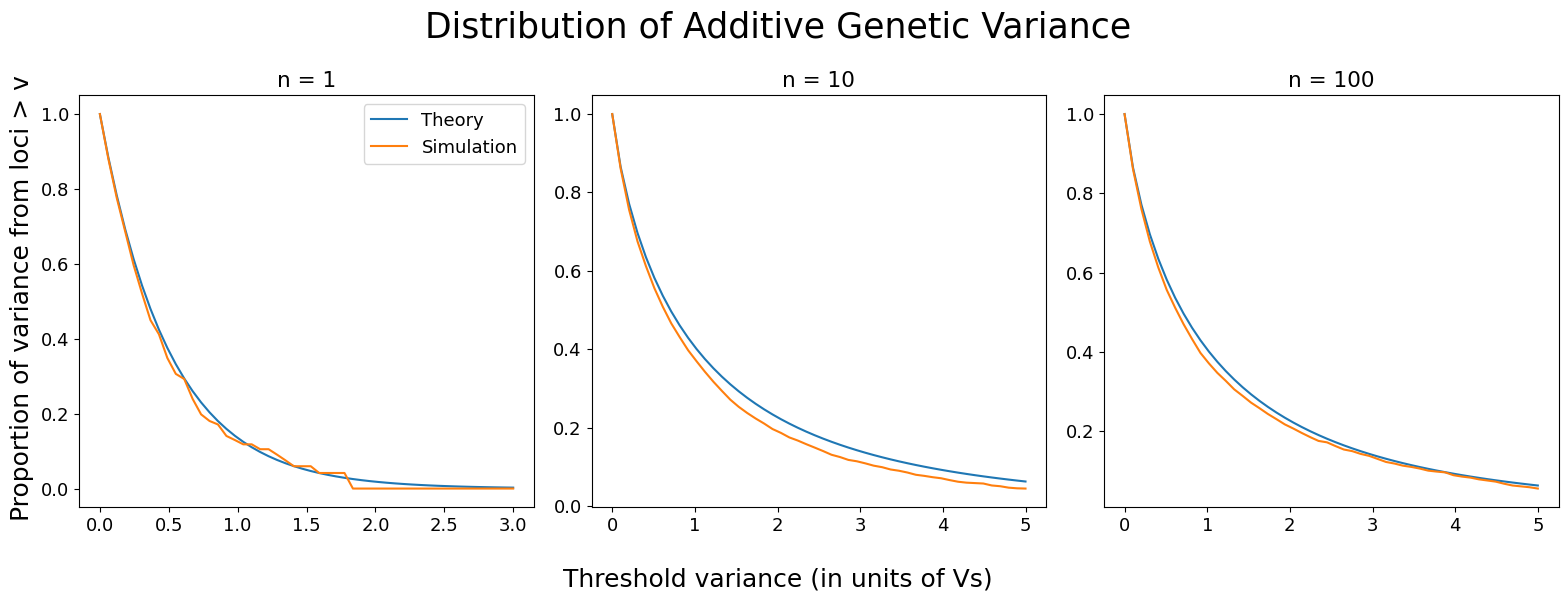

In [12]:
# Plot the results
plt.rcParams.update({'font.size': 13})
fig, axs = plt.subplots(1,3, tight_layout=True, figsize=(16, 6))

axs[0].plot(xaxis_single, theoretical_single, label="Theory")
axs[0].plot(n1_df["xaxis"], n1_df["data"], label="Simulation")
axs[0].set_title("n = 1")
axs[0].legend()

axs[1].plot(xaxis, theoretical_pleiotropy, label="Theoretical")
axs[1].plot(n10_df["xaxis"], n10_df["data"], label="Simulation")
axs[1].set_title("n = 10")

axs[2].plot(xaxis, theoretical_pleiotropy, label="Theoretical")
axs[2].plot(n100_df["xaxis"], n100_df["data"], label="Simulation")
axs[2].set_title("n = 100")


fig.supylabel("Proportion of variance from loci > v", fontsize=18)
fig.supxlabel("Threshold variance (in units of Vs)", fontsize=18)
fig.suptitle("Distribution of Additive Genetic Variance", fontsize=25)

plt.savefig("distribution_additive_genetic_variance.pdf")

plt.show()